In [213]:
import torch
from torch import nn

In [214]:
n = 5
v_min = -10
v_max = 10
delta_z = (v_max - v_min) / 5
delta_z

z = torch.linspace(v_min, v_max, n)
z

tensor([-10.,  -5.,   0.,   5.,  10.])

In [215]:
p = torch.tensor([0.1, 0.2, 0.4, 0.2, 0.1])
q = (z * p).sum()
q

tensor(0.)

Nie da sie dostac 15, bo maksymalna wartosc to 10
gdy p = [0, 0, 0, 0, 1]

In [216]:
gamma = 0.99
k = 1000

k_t = torch.linspace(0, k - 1, k)
gamma_t = torch.repeat_interleave(torch.tensor(gamma), k)
(gamma_t ** k_t).sum()

tensor(99.9958)

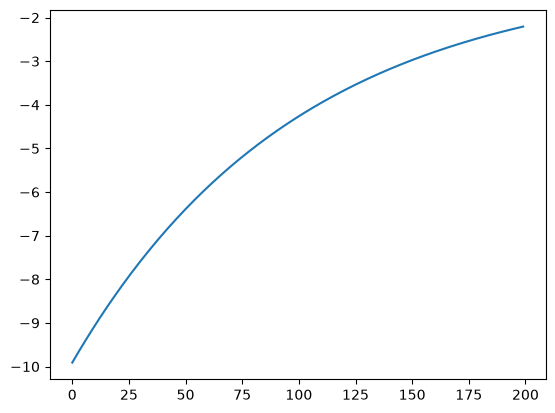

(tensor(-9.9100), tensor(0))

In [217]:
import matplotlib.pyplot as plt

K = 200
steps = torch.arange(K)
penalties = -0.01 * gamma**steps
step_cost = torch.cumsum(penalties, dim=0)
death_cost = -10 * gamma ** (steps + 1)
returns = step_cost + death_cost

plt.plot(steps, returns)
plt.show()
returns.min(), returns.argmin()

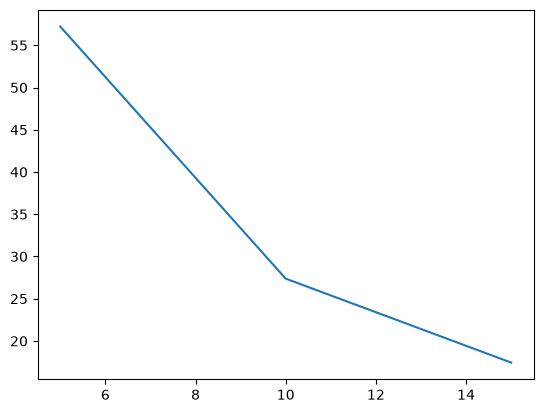

tensor(57.2121)

In [218]:
T = torch.tensor([5, 10, 15])

G = 3 * gamma ** T / (1 - gamma ** T) - 1

plt.plot(T, G)
plt.show()
G.max()


In [219]:
def estimate_support_range(
    gamma: float,
    apple_reward: float,
    step_reward: float,
    death_reward: float,
    apple_interval: int,
) -> tuple[float, float]:
    if not 0 < gamma < 1:
        raise ValueError("gamma must be in (0, 1)")
    if apple_interval <= 0:
        raise ValueError("apple_interval must be positive")

    gamma_t = gamma**apple_interval
    v_min = step_reward + gamma * death_reward
    v_max = apple_reward * gamma_t / (1 - gamma_t) + step_reward / (1 - gamma)
    return v_min, v_max


def atom_spacing(v_min: float, v_max: float, n_atoms: int = 51) -> float:
    return (v_max - v_min) / (n_atoms - 1)


BASE = dict(
    gamma=0.99,
    apple_reward=3,
    step_reward=-0.01,
    death_reward=-10,
    apple_interval=10,
)
estimate_support_range(**BASE)


(-9.91, 27.374870352773677)

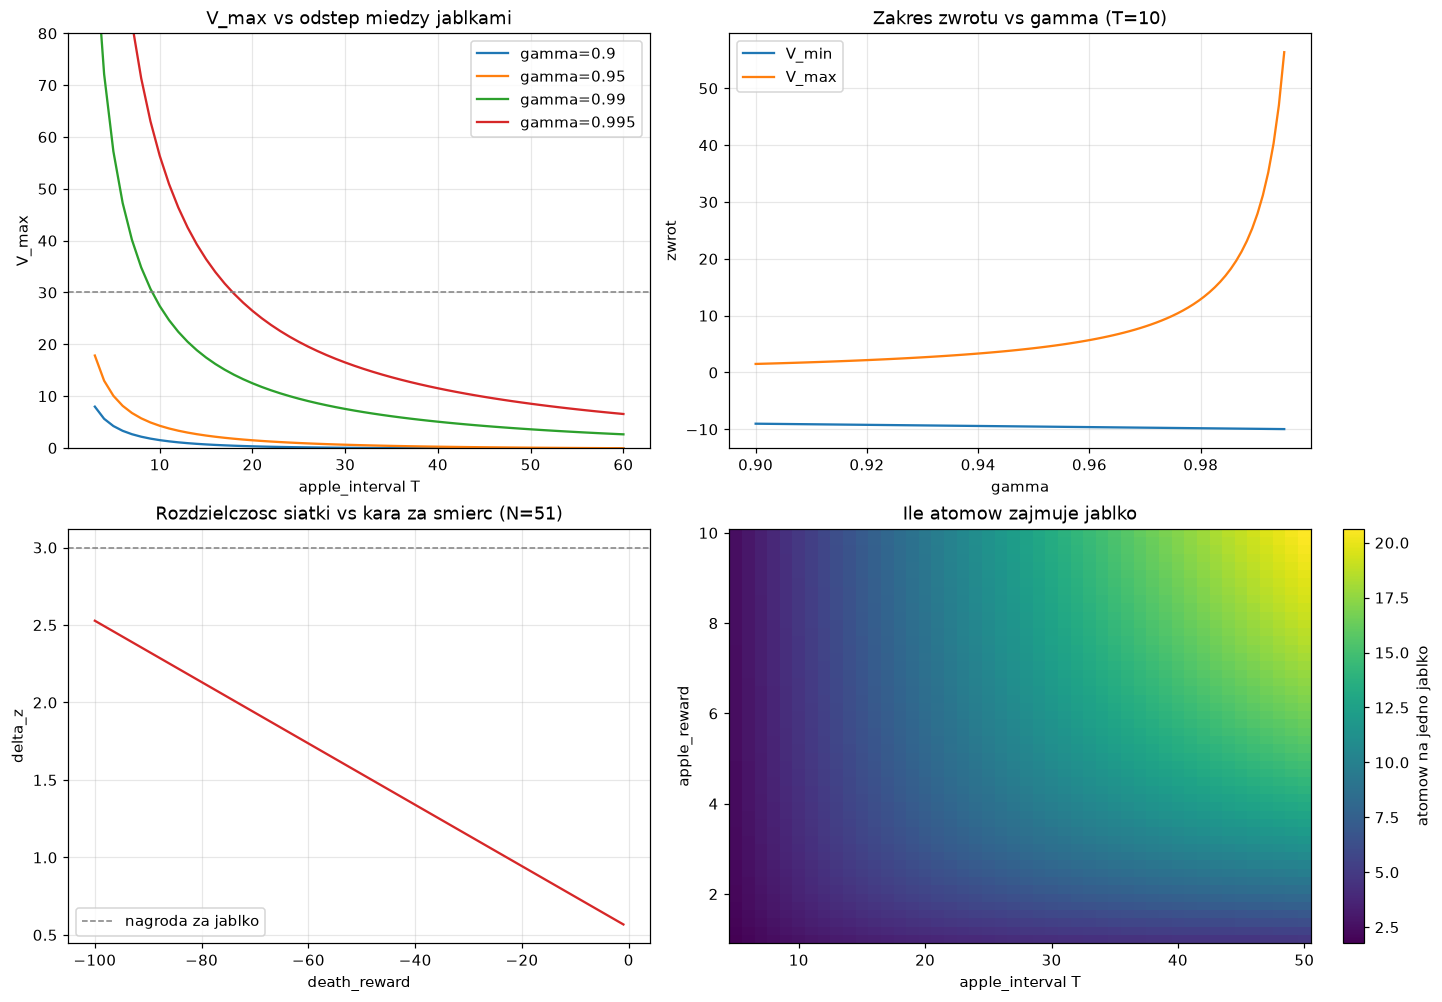

In [220]:
import numpy as np

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

ax = axes[0, 0]
intervals = np.arange(3, 61)
for g in (0.9, 0.95, 0.99, 0.995):
    v_max = [estimate_support_range(**{**BASE, "gamma": g, "apple_interval": int(t)})[1] for t in intervals]
    ax.plot(intervals, v_max, label=f"gamma={g}")
ax.axhline(30, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 80)
ax.set(title="V_max vs odstep miedzy jablkami", xlabel="apple_interval T", ylabel="V_max")
ax.legend()

ax = axes[0, 1]
gammas = np.linspace(0.9, 0.995, 100)
bounds = np.array([estimate_support_range(**{**BASE, "gamma": g}) for g in gammas])
ax.plot(gammas, bounds[:, 0], label="V_min")
ax.plot(gammas, bounds[:, 1], label="V_max")
ax.set(title="Zakres zwrotu vs gamma (T=10)", xlabel="gamma", ylabel="zwrot")
ax.legend()

ax = axes[1, 0]
deaths = np.linspace(-100, -1, 100)
spacing = [
    atom_spacing(*estimate_support_range(**{**BASE, "death_reward": d})) for d in deaths
]
ax.plot(deaths, spacing, color="tab:red")
ax.axhline(BASE["apple_reward"], color="gray", linestyle="--", linewidth=1, label="nagroda za jablko")
ax.set(title="Rozdzielczosc siatki vs kara za smierc (N=51)", xlabel="death_reward", ylabel="delta_z")
ax.legend()

ax = axes[1, 1]
apple_rewards = np.linspace(1, 10, 50)
intervals_h = np.arange(5, 51)
atoms_per_apple = np.array(
    [
        [
            a / atom_spacing(*estimate_support_range(**{**BASE, "apple_reward": a, "apple_interval": int(t)}))
            for t in intervals_h
        ]
        for a in apple_rewards
    ]
)
mesh = ax.pcolormesh(intervals_h, apple_rewards, atoms_per_apple, shading="auto", cmap="viridis")
fig.colorbar(mesh, ax=ax, label="atomow na jedno jablko")
ax.grid(False)
ax.set(title="Ile atomow zajmuje jablko", xlabel="apple_interval T", ylabel="apple_reward")

plt.show()
